# EDA: Geospatial & Distance Analysis

**Phase 1 — EDA & Data Understanding**

Analysis of spatial/distance features and fire movement dynamics.

**Note:** The dataset does not include raw lat/lon coordinates. Geospatial analysis
focuses on the pre-computed distance, directionality, and centroid kinematics features.

**Goals:**
- Proximity analysis: distance distributions fire-to-infrastructure
- Fire movement patterns: centroid kinematics, spread bearing
- Directionality: alignment between fire movement and evacuation zone
- Regional patterns via temporal metadata (month, hour)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.gcf().savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

train = pd.read_csv("../data/raw/train.csv")

## 1. Distance to Evacuation Zone

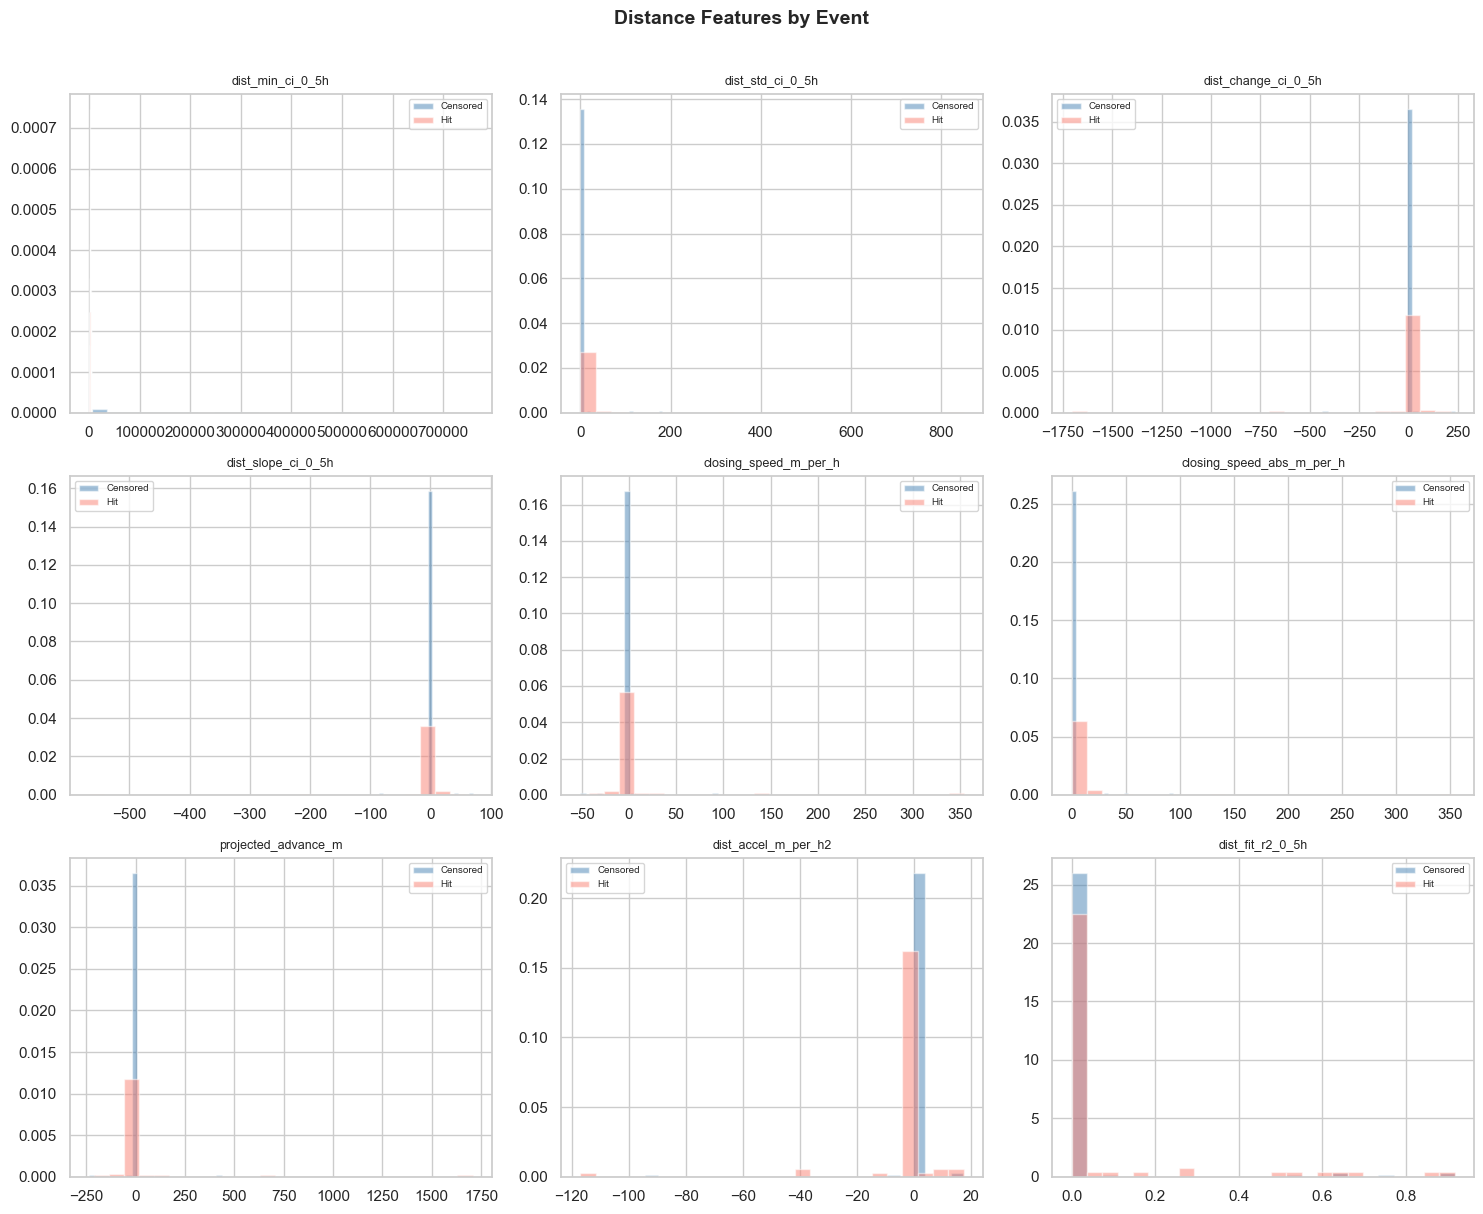

In [2]:
distance_cols = [
    "dist_min_ci_0_5h", "dist_std_ci_0_5h", "dist_change_ci_0_5h",
    "dist_slope_ci_0_5h", "closing_speed_m_per_h", "closing_speed_abs_m_per_h",
    "projected_advance_m", "dist_accel_m_per_h2", "dist_fit_r2_0_5h"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(distance_cols):
    ax = axes[i]
    for ev, color, label in [(0, "steelblue", "Censored"), (1, "salmon", "Hit")]:
        subset = train[train["event"] == ev][col]
        ax.hist(subset, bins=25, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Distance Features by Event", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("distance_features_by_event")
plt.show()

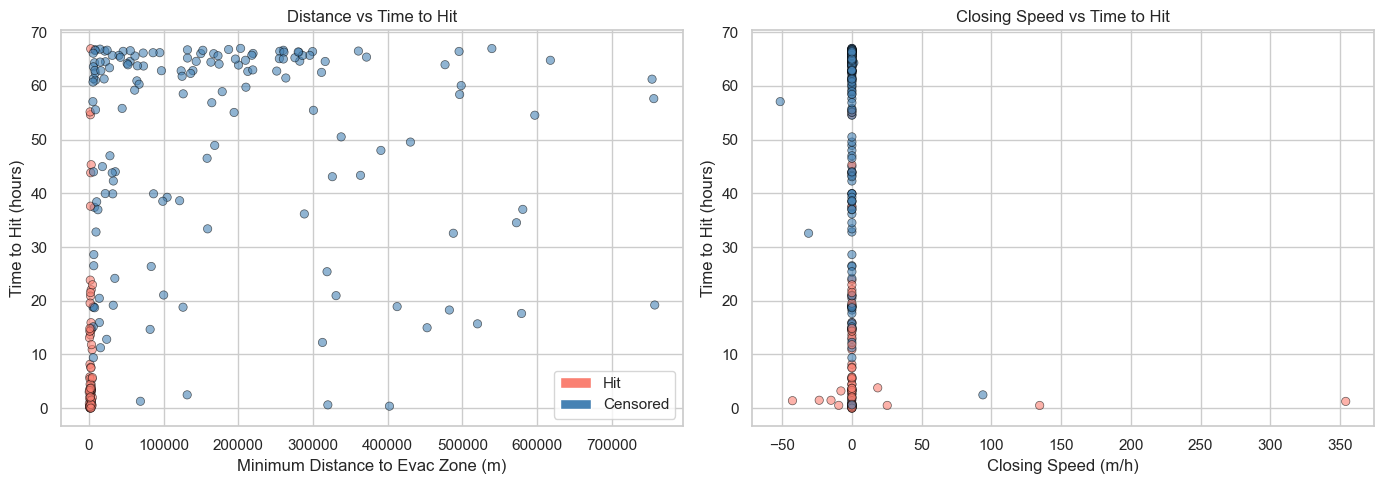

In [3]:
# Minimum distance vs time-to-hit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: dist_min_ci_0_5h vs time_to_hit_hours
colors = train["event"].map({0: "steelblue", 1: "salmon"})
axes[0].scatter(train["dist_min_ci_0_5h"], train["time_to_hit_hours"],
                c=colors, alpha=0.6, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Minimum Distance to Evac Zone (m)")
axes[0].set_ylabel("Time to Hit (hours)")
axes[0].set_title("Distance vs Time to Hit")

# Scatter: closing_speed vs time_to_hit_hours
axes[1].scatter(train["closing_speed_m_per_h"], train["time_to_hit_hours"],
                c=colors, alpha=0.6, edgecolor="black", linewidth=0.5)
axes[1].set_xlabel("Closing Speed (m/h)")
axes[1].set_ylabel("Time to Hit (hours)")
axes[1].set_title("Closing Speed vs Time to Hit")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="salmon", label="Hit"), Patch(facecolor="steelblue", label="Censored")]
axes[0].legend(handles=legend_elements)

plt.tight_layout()
save_fig("distance_vs_time_to_hit")
plt.show()

In [4]:
# Distance statistics by event
print("=== dist_min_ci_0_5h by event ===")
print(train.groupby("event")["dist_min_ci_0_5h"].describe().T)
print("\n=== closing_speed_m_per_h by event ===")
print(train.groupby("event")["closing_speed_m_per_h"].describe().T)

=== dist_min_ci_0_5h by event ===
event              0            1
count     152.000000    69.000000
mean   179832.303100  2285.818350
std    181234.881270  1018.185360
min      5215.748715   306.954551
25%     27921.740395  1464.568356
50%    128842.069272  2429.801581
75%    281365.349584  2798.867829
max    757700.487102  4673.854411

=== closing_speed_m_per_h by event ===
event           0           1
count  152.000000   69.000000
mean     0.081931    6.293863
std      9.072713   46.101181
min    -51.397494  -42.625315
25%      0.000000    0.000000
50%      0.000000    0.000000
75%      0.000000    0.000000
max     93.922570  354.120897


## 2. Centroid Kinematics — Fire Movement

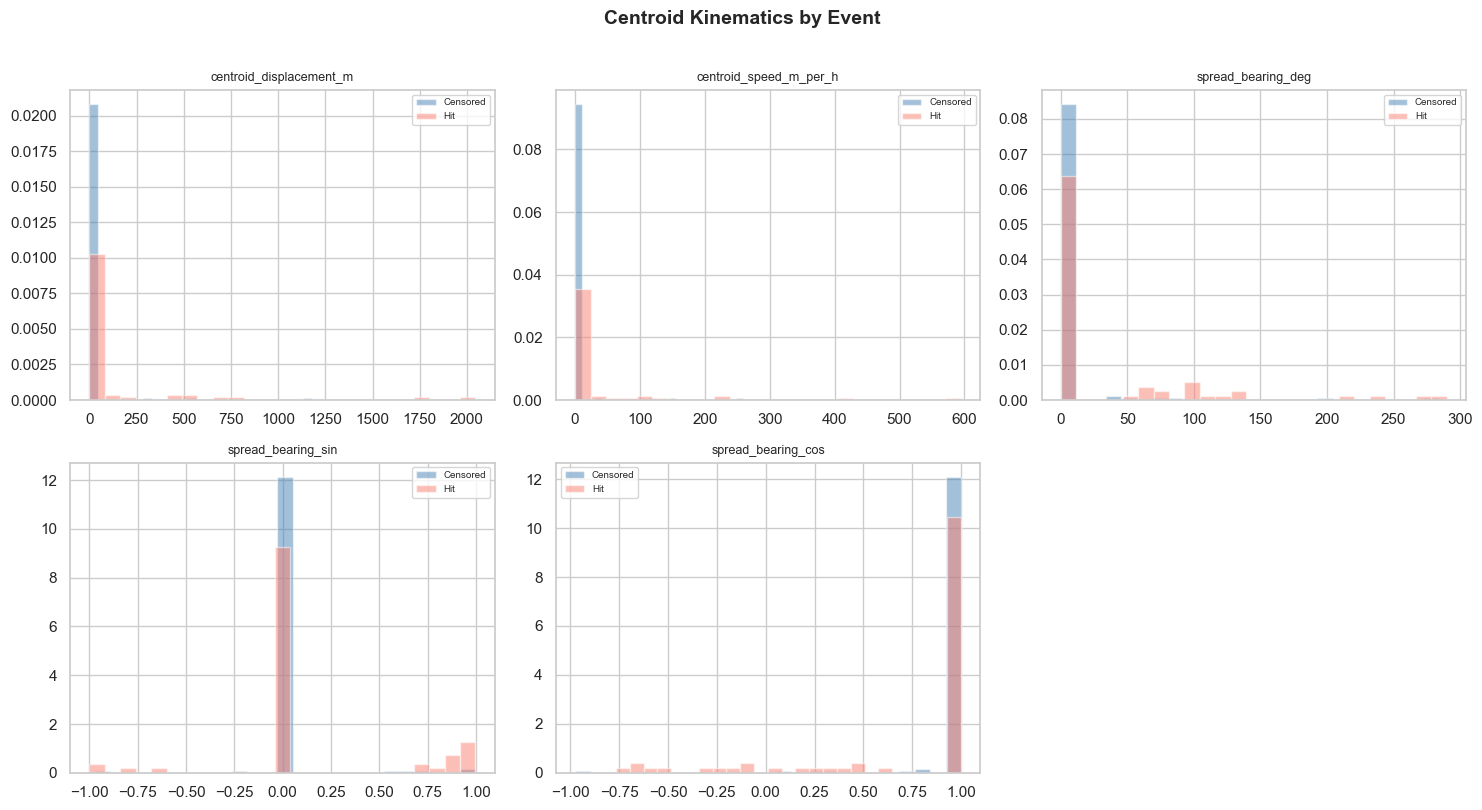

In [5]:
kinematic_cols = [
    "centroid_displacement_m", "centroid_speed_m_per_h",
    "spread_bearing_deg", "spread_bearing_sin", "spread_bearing_cos"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(kinematic_cols):
    ax = axes[i]
    for ev, color, label in [(0, "steelblue", "Censored"), (1, "salmon", "Hit")]:
        subset = train[train["event"] == ev][col]
        ax.hist(subset, bins=25, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle("Centroid Kinematics by Event", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("centroid_kinematics_by_event")
plt.show()

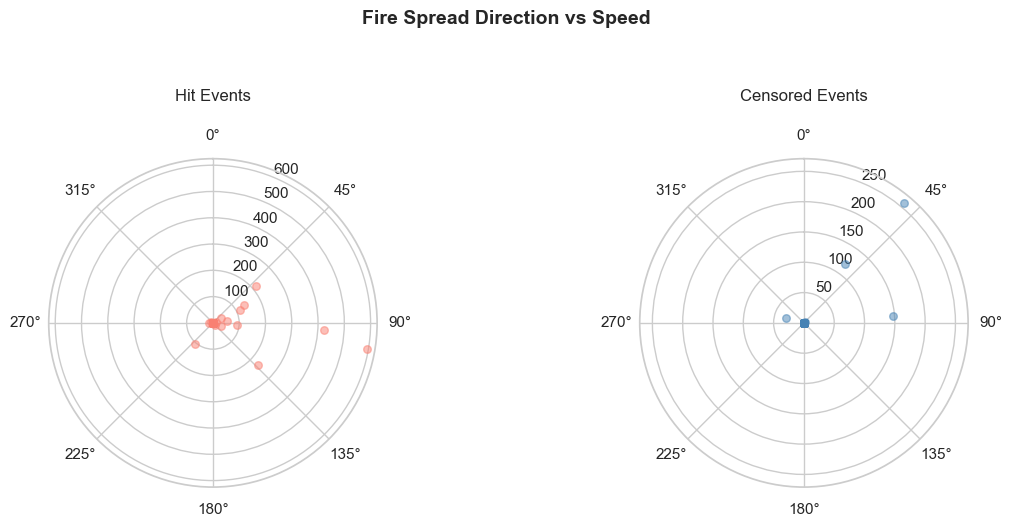

In [6]:
# Polar plot of spread bearing for hit vs censored
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": "polar"})

for ax, (ev, title, color) in zip(axes, [(1, "Hit Events", "salmon"), (0, "Censored Events", "steelblue")]):
    subset = train[train["event"] == ev]
    bearings_rad = np.deg2rad(subset["spread_bearing_deg"])
    ax.scatter(bearings_rad, subset["centroid_speed_m_per_h"], alpha=0.5, c=color, s=30)
    ax.set_title(title, fontsize=12, pad=20)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

plt.suptitle("Fire Spread Direction vs Speed", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
save_fig("spread_bearing_polar")
plt.show()

## 3. Directionality — Fire-to-Evacuation Alignment

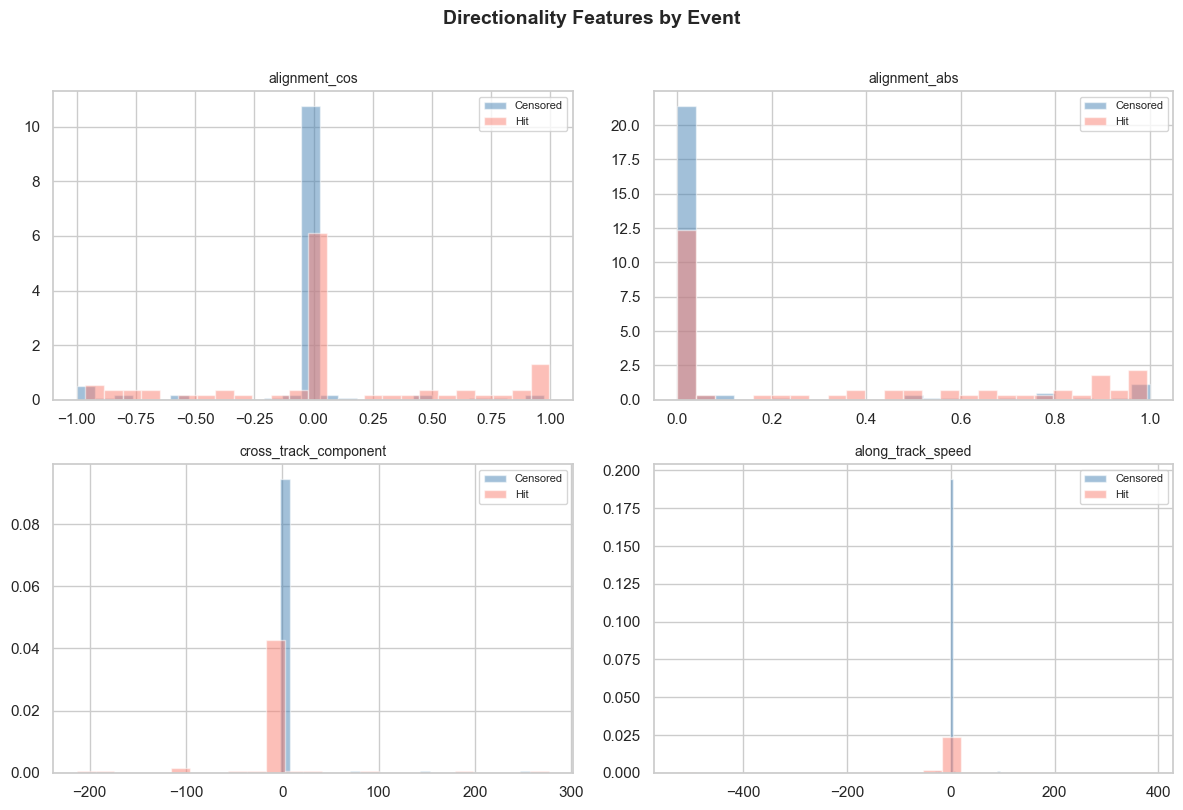

In [7]:
direction_cols = ["alignment_cos", "alignment_abs", "cross_track_component", "along_track_speed"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(direction_cols):
    ax = axes[i]
    for ev, color, label in [(0, "steelblue", "Censored"), (1, "salmon", "Hit")]:
        subset = train[train["event"] == ev][col]
        ax.hist(subset, bins=25, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Directionality Features by Event", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("directionality_by_event")
plt.show()

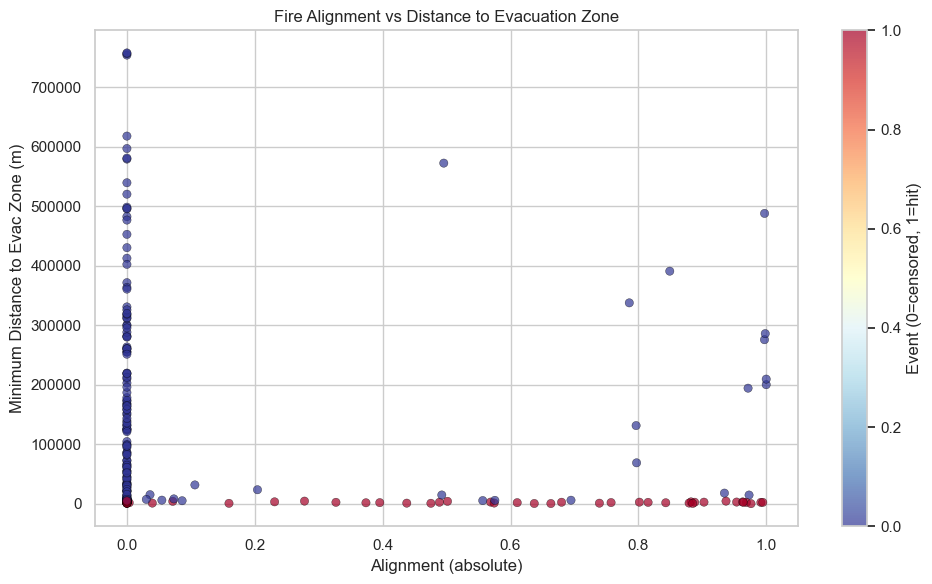

In [8]:
# Alignment vs distance scatter
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(train["alignment_abs"], train["dist_min_ci_0_5h"],
                     c=train["event"], cmap="RdYlBu_r", alpha=0.7,
                     edgecolor="black", linewidth=0.3)
ax.set_xlabel("Alignment (absolute)")
ax.set_ylabel("Minimum Distance to Evac Zone (m)")
ax.set_title("Fire Alignment vs Distance to Evacuation Zone")
plt.colorbar(scatter, label="Event (0=censored, 1=hit)")
plt.tight_layout()
save_fig("alignment_vs_distance")
plt.show()

## 4. Temporal Patterns

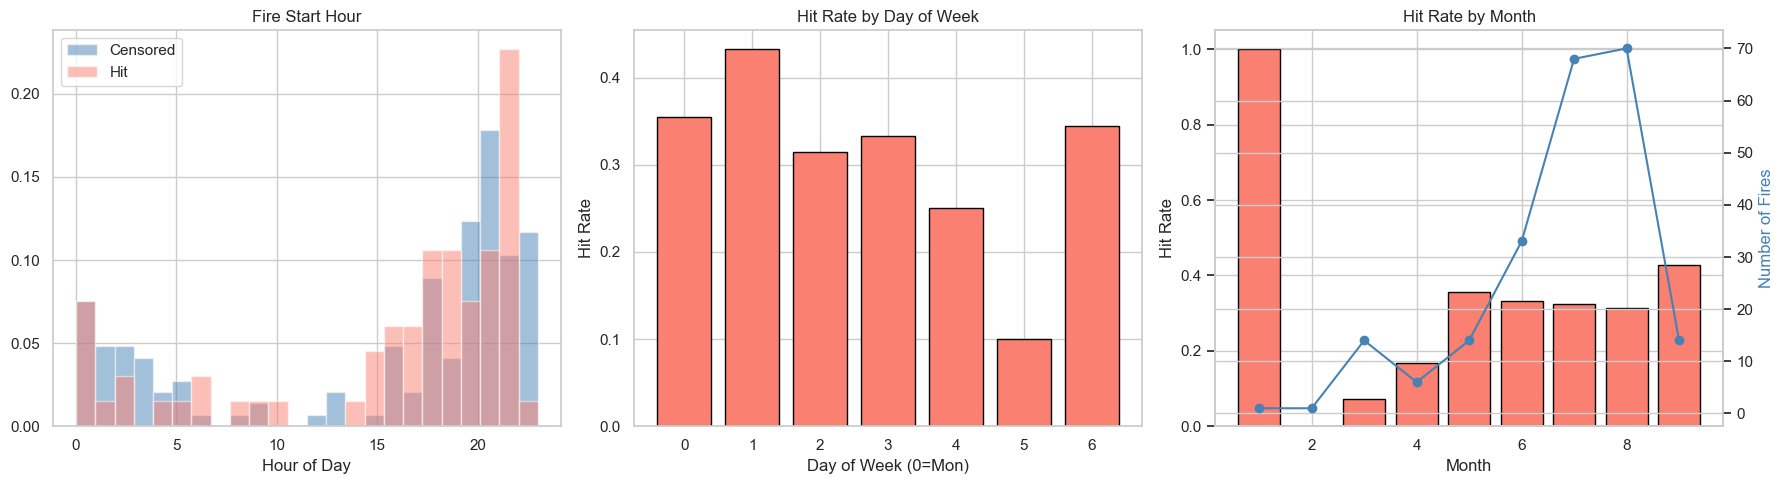

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hour of day
for ev, color, label in [(0, "steelblue", "Censored"), (1, "salmon", "Hit")]:
    subset = train[train["event"] == ev]
    axes[0].hist(subset["event_start_hour"], bins=24, alpha=0.5, color=color, label=label, density=True)
axes[0].set_xlabel("Hour of Day")
axes[0].set_title("Fire Start Hour")
axes[0].legend()

# Day of week
dow_hit_rate = train.groupby("event_start_dayofweek")["event"].mean()
axes[1].bar(dow_hit_rate.index, dow_hit_rate.values, color="salmon", edgecolor="black")
axes[1].set_xlabel("Day of Week (0=Mon)")
axes[1].set_ylabel("Hit Rate")
axes[1].set_title("Hit Rate by Day of Week")

# Month
month_hit_rate = train.groupby("event_start_month")["event"].agg(["mean", "count"])
ax2 = axes[2]
bars = ax2.bar(month_hit_rate.index, month_hit_rate["mean"], color="salmon", edgecolor="black")
ax2.set_xlabel("Month")
ax2.set_ylabel("Hit Rate")
ax2.set_title("Hit Rate by Month")
ax2_twin = ax2.twinx()
ax2_twin.plot(month_hit_rate.index, month_hit_rate["count"], "o-", color="steelblue", label="Count")
ax2_twin.set_ylabel("Number of Fires", color="steelblue")

plt.tight_layout()
save_fig("temporal_patterns")
plt.show()

## 5. Fire Growth Dynamics

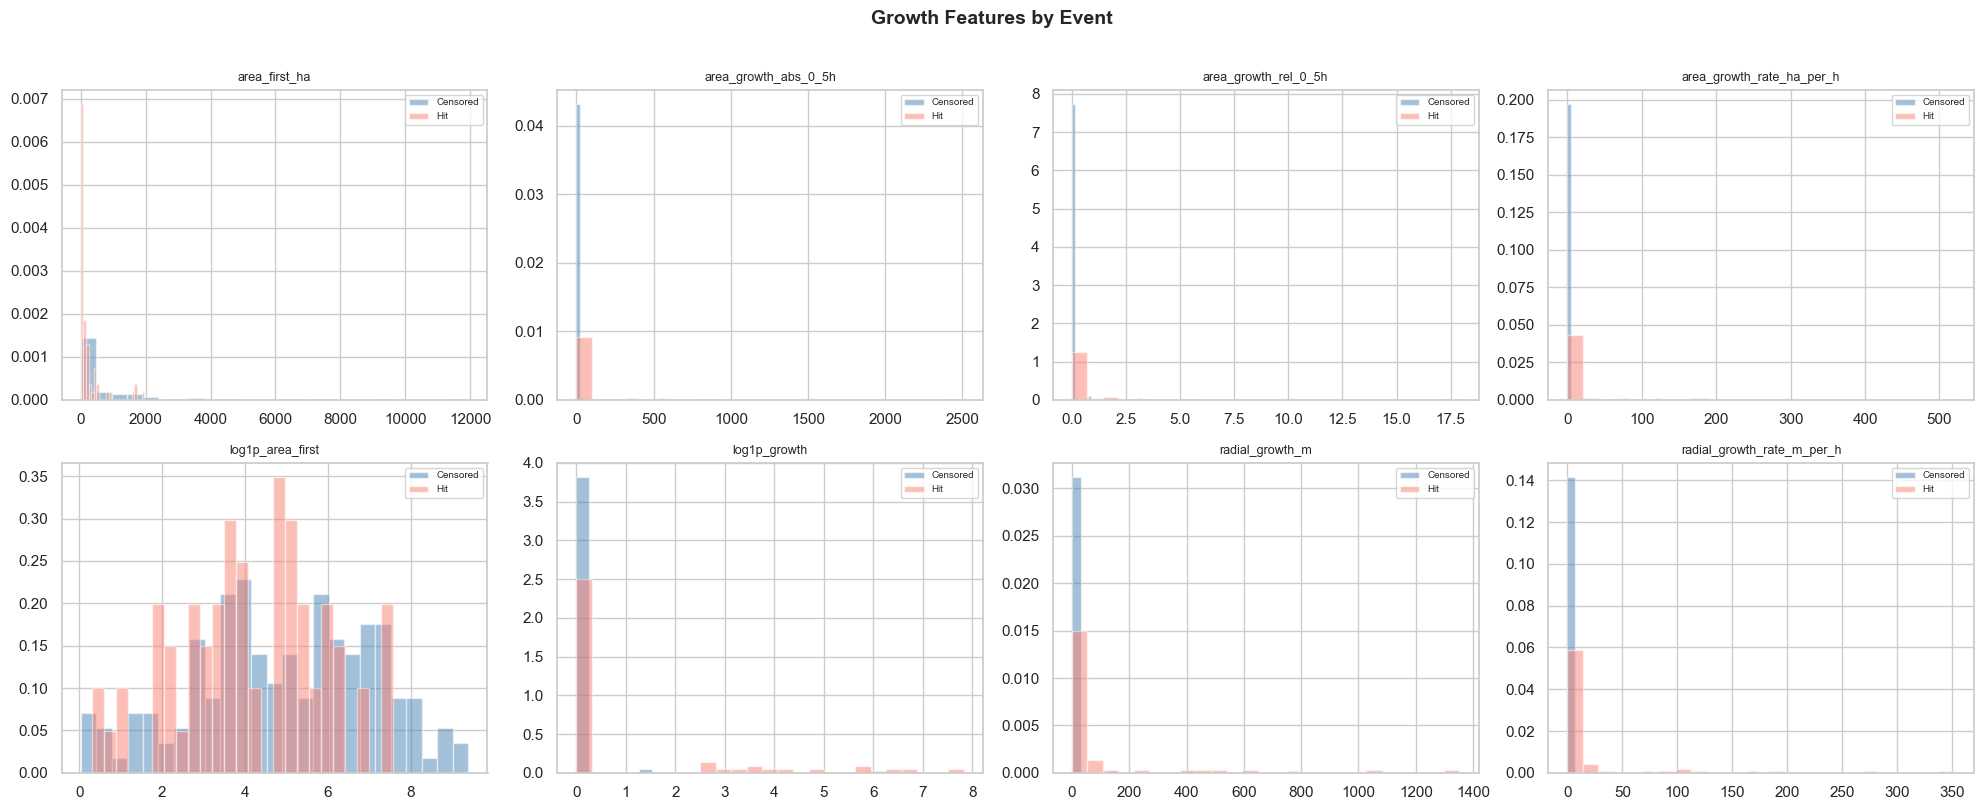

In [10]:
growth_cols = [
    "area_first_ha", "area_growth_abs_0_5h", "area_growth_rel_0_5h",
    "area_growth_rate_ha_per_h", "log1p_area_first", "log1p_growth",
    "radial_growth_m", "radial_growth_rate_m_per_h"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(growth_cols):
    ax = axes[i]
    for ev, color, label in [(0, "steelblue", "Censored"), (1, "salmon", "Hit")]:
        subset = train[train["event"] == ev][col]
        ax.hist(subset, bins=25, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Growth Features by Event", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("growth_features_by_event")
plt.show()

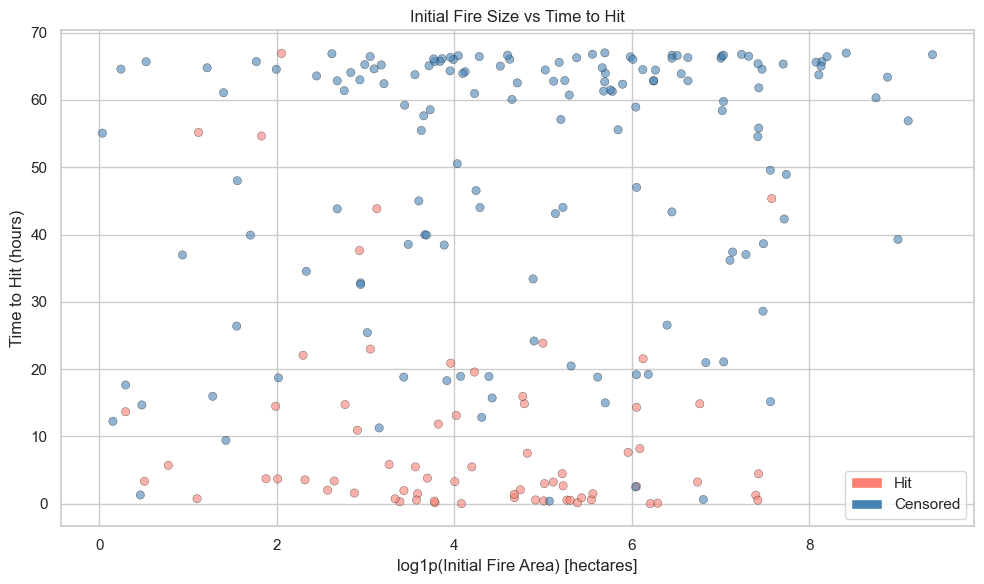

In [11]:
# Initial area vs time to hit
fig, ax = plt.subplots(figsize=(10, 6))
colors = train["event"].map({0: "steelblue", 1: "salmon"})
ax.scatter(train["log1p_area_first"], train["time_to_hit_hours"],
           c=colors, alpha=0.6, edgecolor="black", linewidth=0.3)
ax.set_xlabel("log1p(Initial Fire Area) [hectares]")
ax.set_ylabel("Time to Hit (hours)")
ax.set_title("Initial Fire Size vs Time to Hit")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="salmon", label="Hit"), Patch(facecolor="steelblue", label="Censored")])
plt.tight_layout()
save_fig("fire_size_vs_time_to_hit")
plt.show()

## 6. Key Findings

### Distance
- `dist_min_ci_0_5h` is the strongest discriminator — hit events have much shorter initial distances
- Closing speed and projected advance show clear separation between hit/censored

### Directionality
- Higher `alignment_abs` (fire moving toward evac zone) correlates with hits
- Many events have zero alignment (fire not moving toward evac zone)

### Temporal
- Fire start hour shows some pattern — afternoon/evening fires may behave differently
- Monthly patterns exist but sample sizes are small

### Growth
- Initial fire area (`area_first_ha`) varies widely
- Most fires show zero growth in the 0-5h observation window (sparse features)
- When growth occurs, hit events tend to show larger growth